# Test Calibration Workflow

In [1]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"  
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import pandas as pd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from esem.utils import get_random_params

import above_library.plotting as plotting
import above_library.emulation as em
import above_library.processing as proc
import above_library.utils as utils

/glade/work/afoster/conda-envs/above/lib/python3.12/site-packages/esem/__init__.py:13: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## Set Up

In [2]:
config_dir = '/glade/work/afoster/ABoVE/calibration_configs'
config_file = os.path.join(config_dir, 'black_spruce.yaml')
ensemble_config = utils.get_config_file(config_file)

var_config_file = '/glade/work/afoster/ABoVE/model_vars.yaml'
var_config = utils.get_config_file(var_config_file)

fig_dir = '/glade/work/afoster/ABoVE/figures'

In [3]:
pft = 'black_spruce'
rank = 1
out_file = os.path.join('/glade/work/afoster/ABoVE/parameter_outputs', f"params_{pft}_{rank}.csv")

In [5]:
existing_df = pd.read_csv(out_file)
start_id = int(existing_df['run_id'].max()) + 1

In [6]:
start_id

52

### Get Needed Data & Emulators

In [ ]:
lh_key = pd.read_csv(ensemble_config['lhc_key_file'], index_col=[0])
lh_key = lh_key.drop(columns=['ensemble'])
param_names = lh_key.columns

obs = xr.open_dataset(ensemble_config['obs_df'])
obs_mean = obs.sel(type='mean')
obs_std = obs.sel(type='std')

pft = ensemble_config['pft']
calibration_vars = [f"{pft}_{variable}" for variable in ensemble_config['variables']]
calibration_labels = [var_config[variable]['long_name'] for variable in ensemble_config['variables']]
calibration_units = [var_config[variable]['units'] for variable in ensemble_config['variables']]

emulators = em.load_emulators(ensemble_config['emulator_dir'], calibration_vars)
targets = [obs_mean[v].values for v in ensemble_config['variables']]
sds = [obs_std[v].values for v in ensemble_config['variables']]

## Calibrate

In [ ]:
iteration = 3

In [ ]:
sample = get_random_params(len(param_names), int(float(ensemble_config['sample_size'])))
if update_pars is not None:
    sample = em.update_sample(sample, update_pars, param_names)
df = pd.DataFrame(sample)
df.columns = param_names

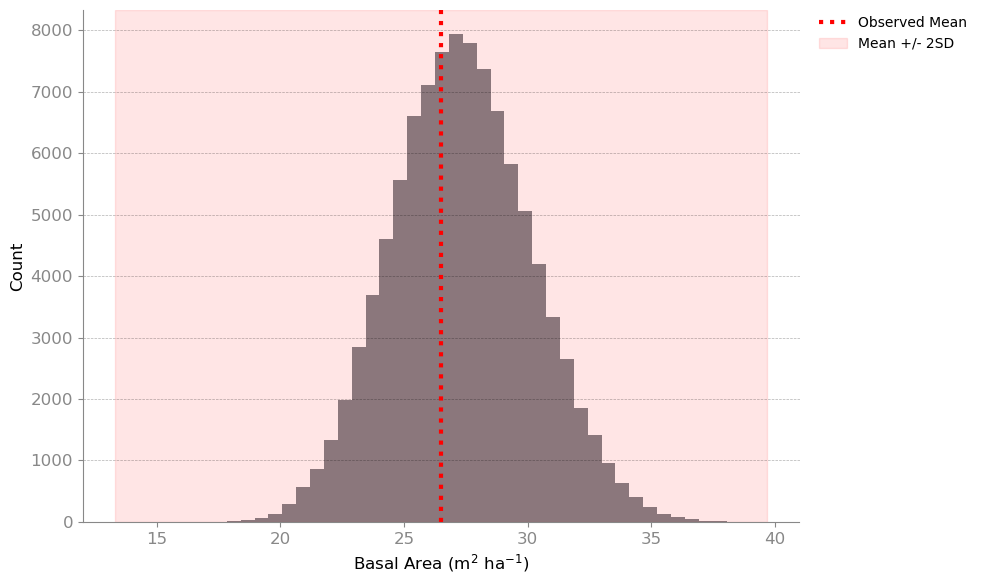

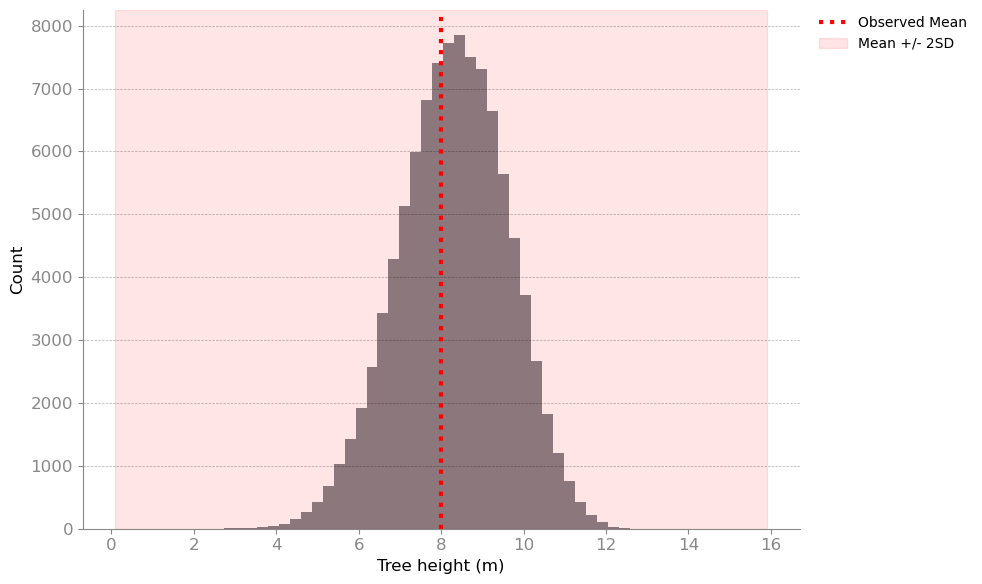

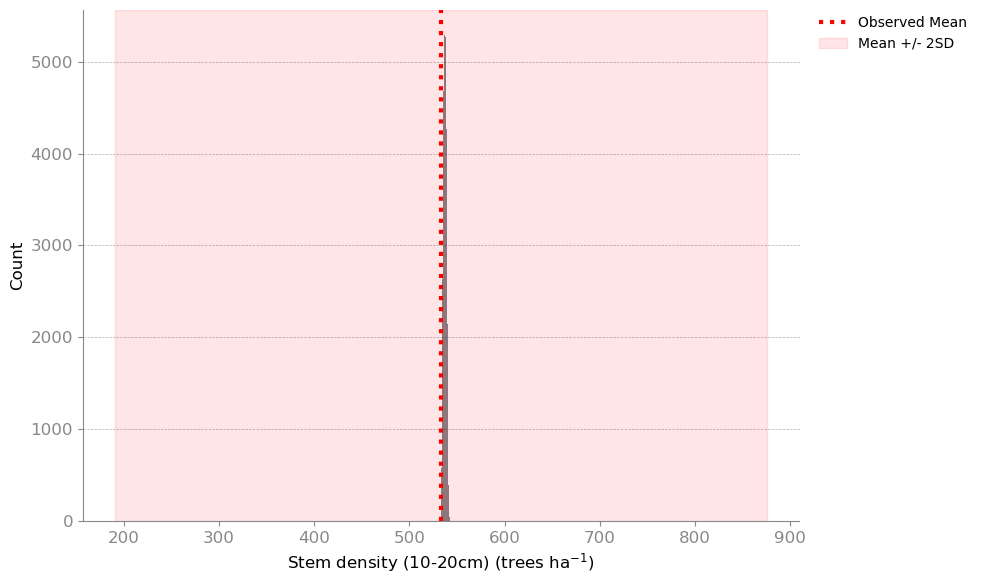

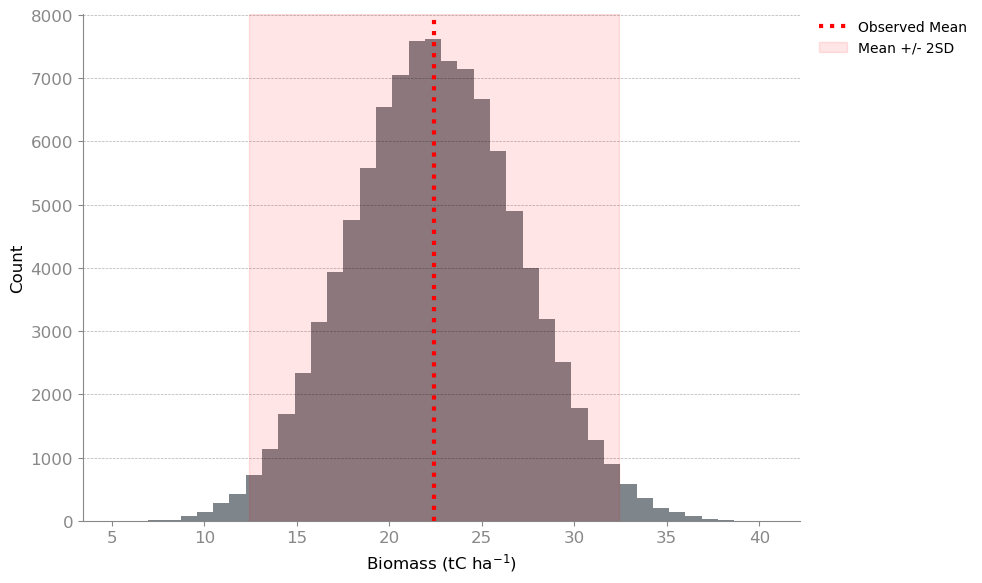

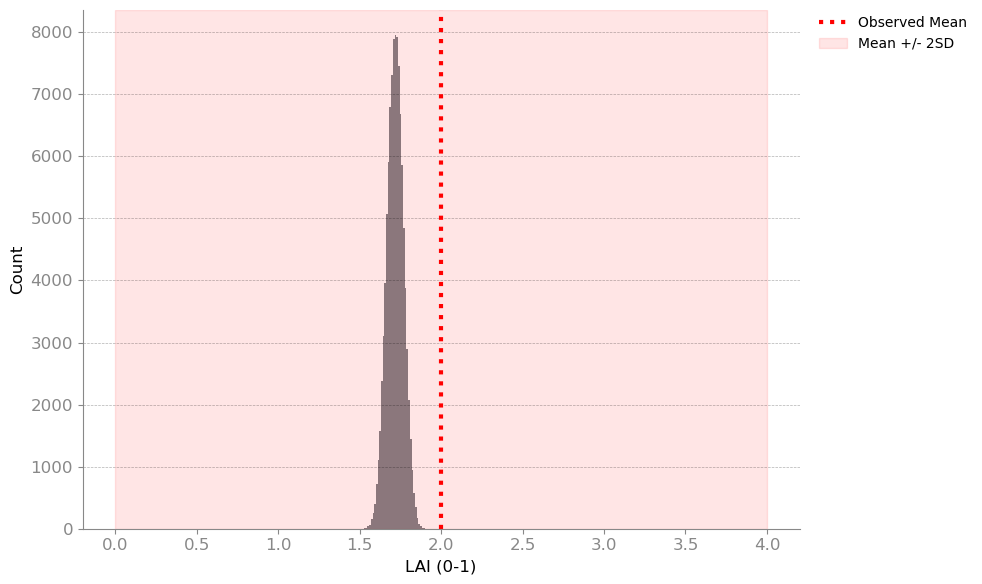

In [128]:
sens_dats = []
for i, emulator in enumerate(emulators):
    sens_df = em.sensitivity_analysis(emulator, param_names, update_pars=update_pars)
    sens_df["variable"] = calibration_vars[i]
    sens_dats.append(sens_df)
    y_pred, y_var = em.chunked_emulation(emulator, sample)
    plotting.plot_sample(y_pred, calibration_labels[i], calibration_units[i], obs_mean=targets[i], obs_sd=sds[i])
    plt.savefig(os.path.join(fig_dir, f'{calibration_vars[i]}_sample_{iteration}.png'))
    implaus = em.implausibility_metric(y_pred, targets[i], y_var, sds[i] ** 2)
    df[f"{calibration_vars[i]}_implaus"] = implaus
sens_df = pd.concat(sens_dats)

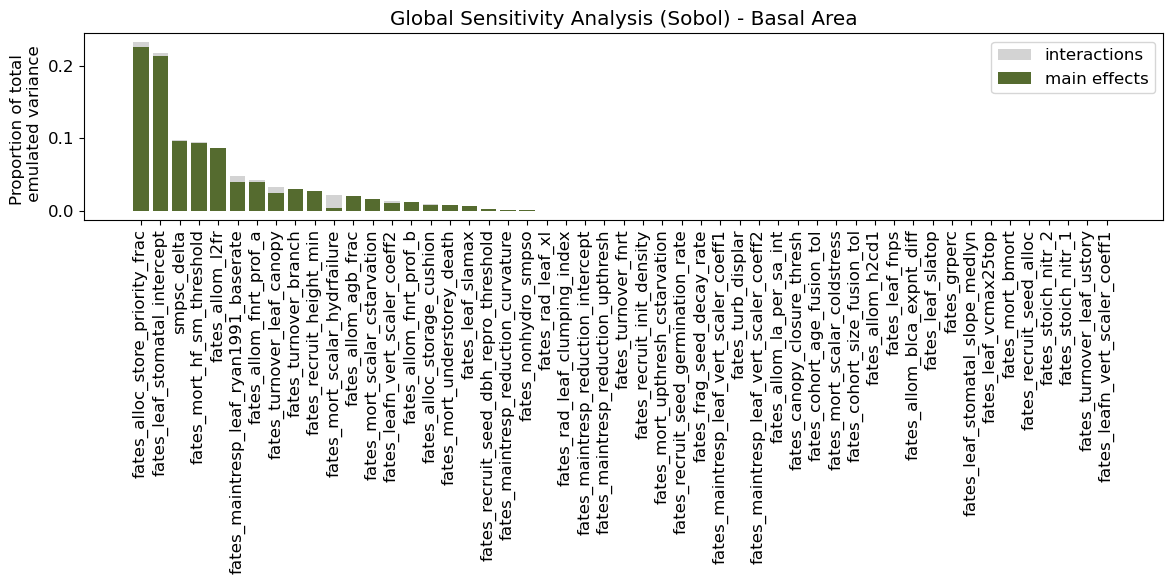

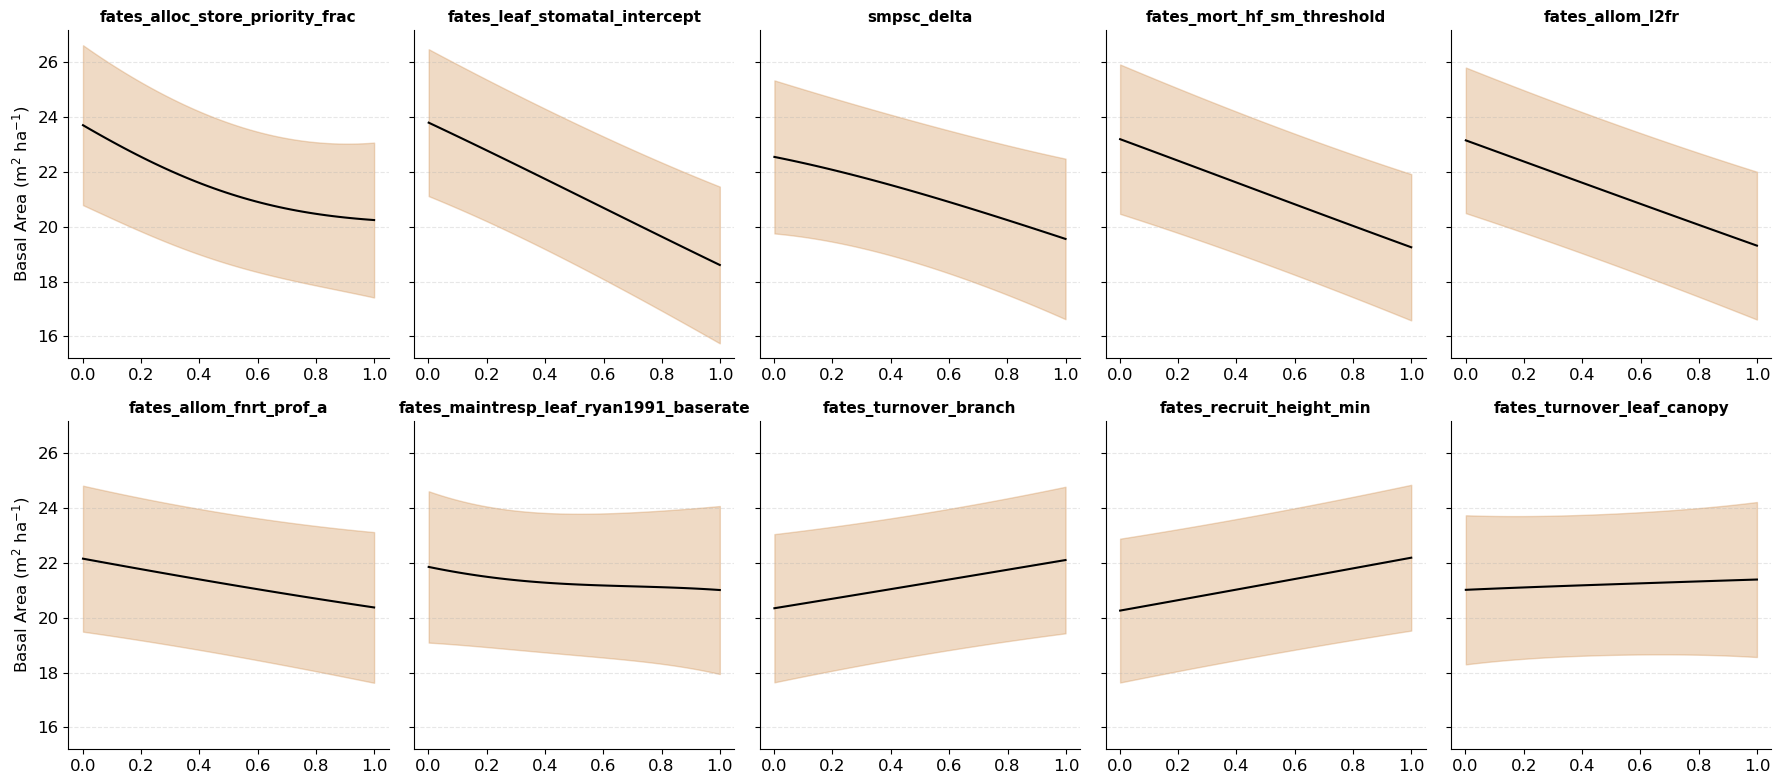

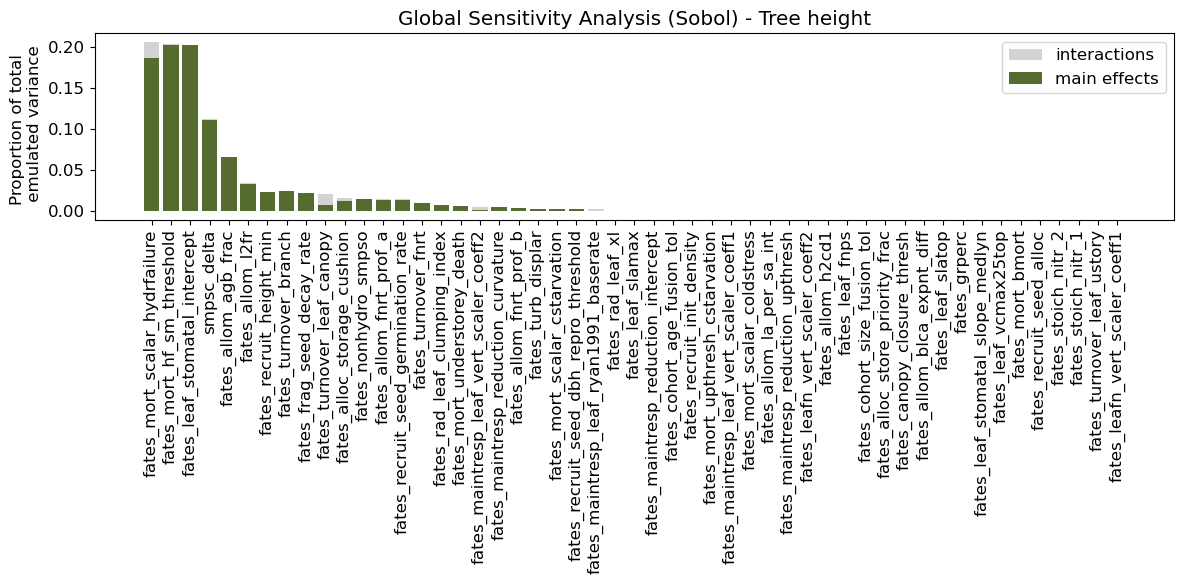

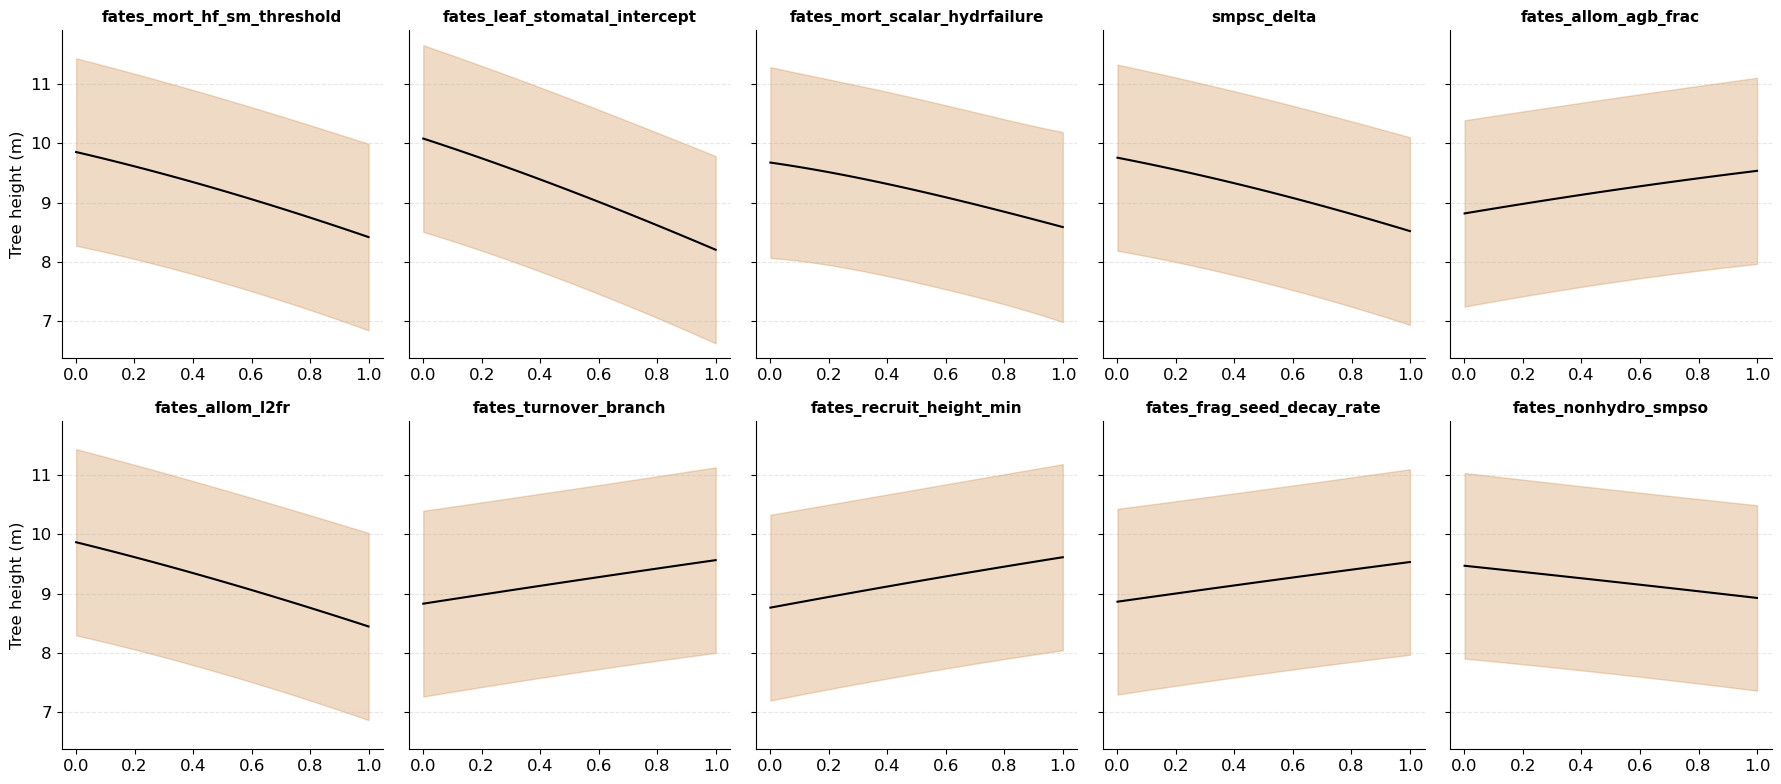

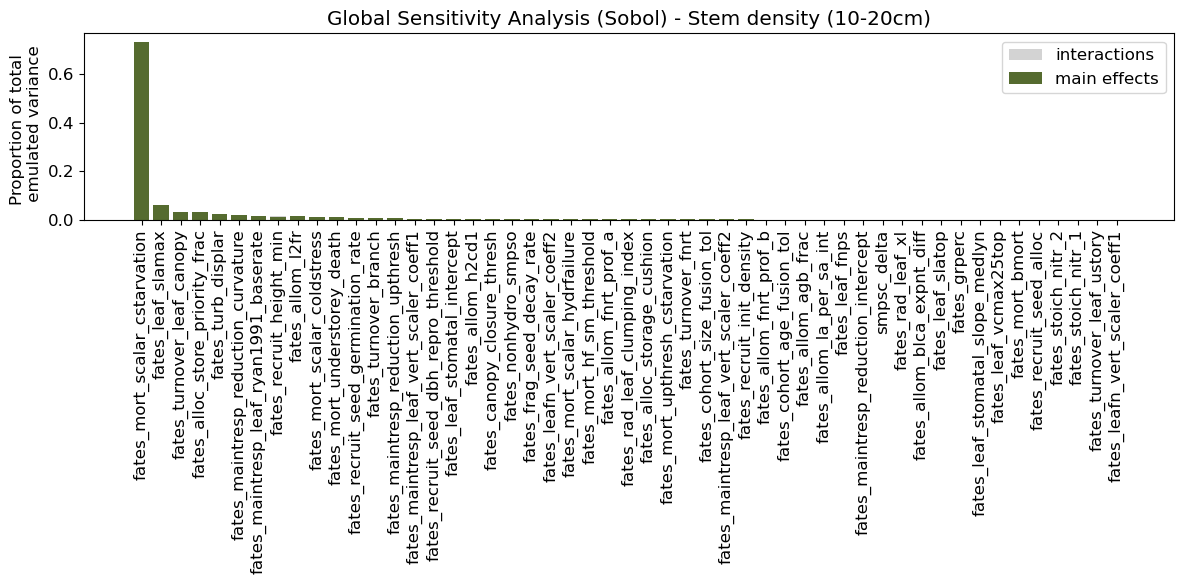

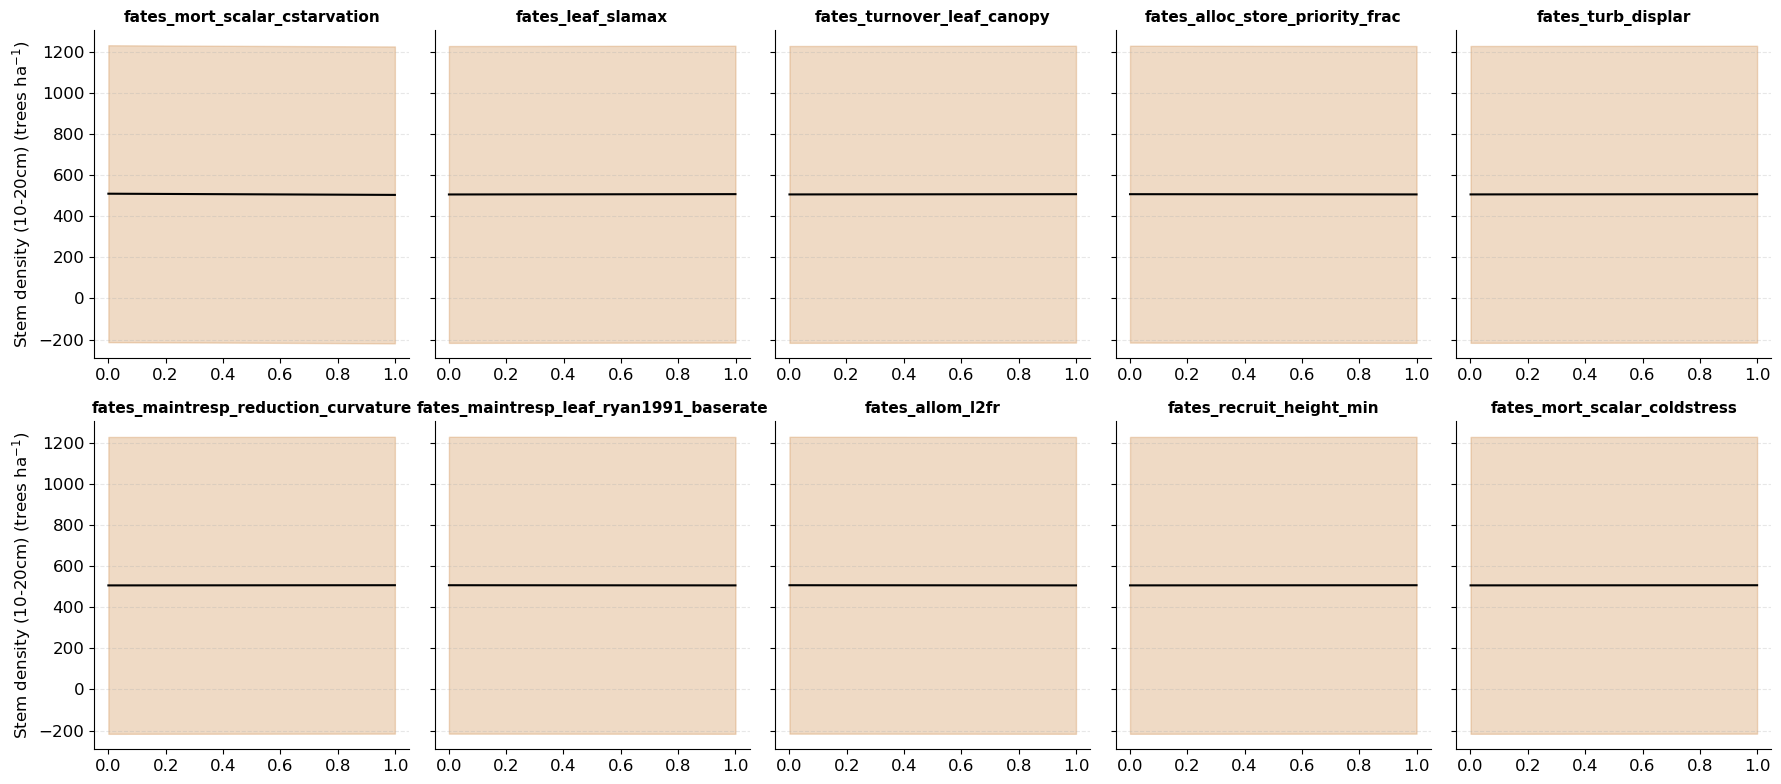

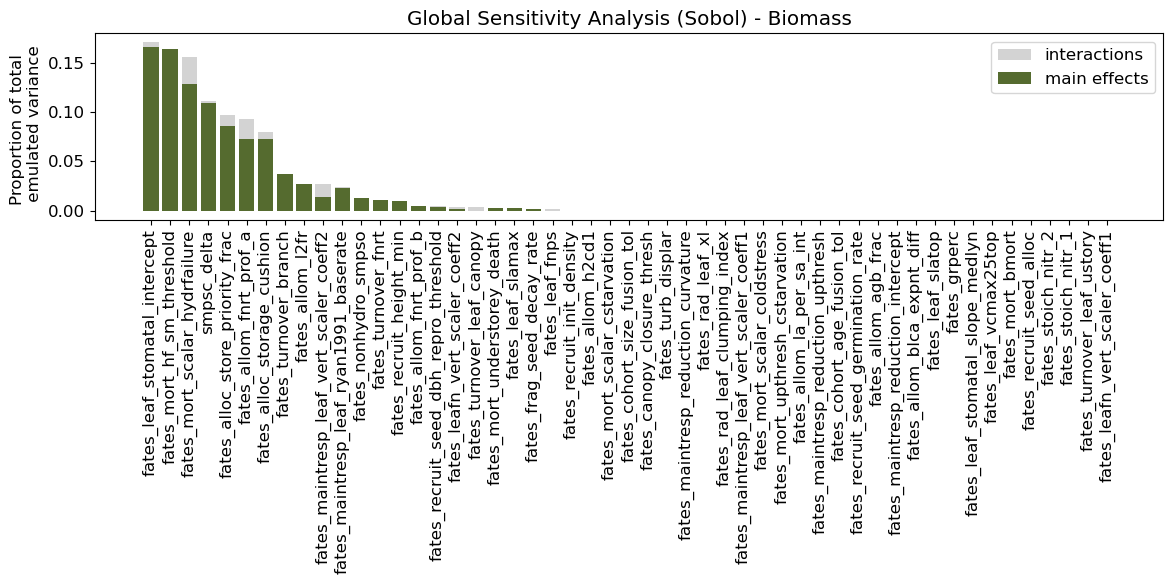

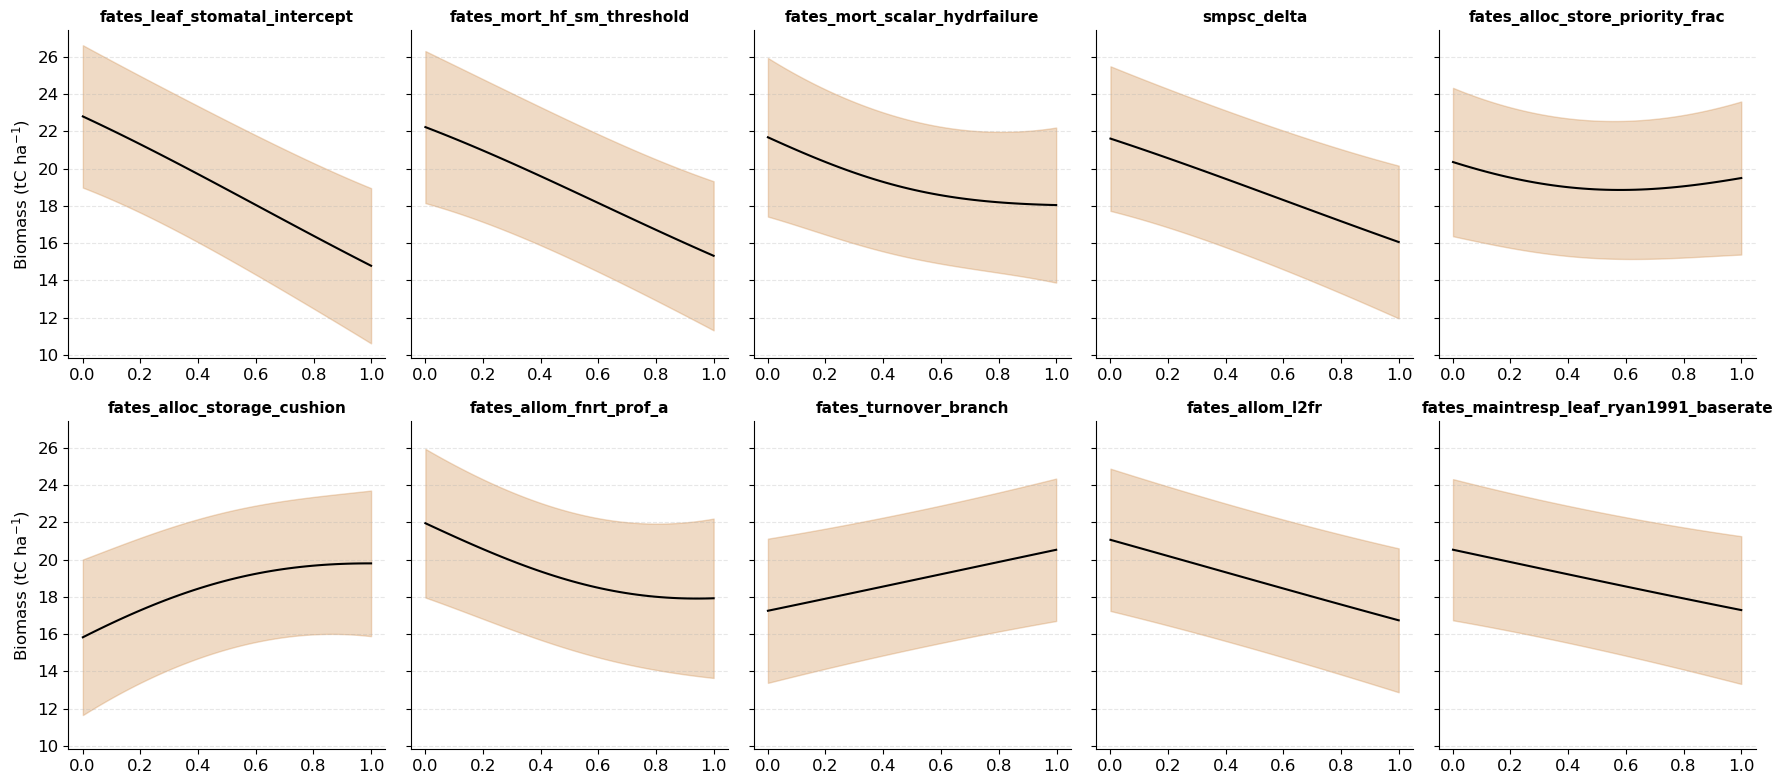

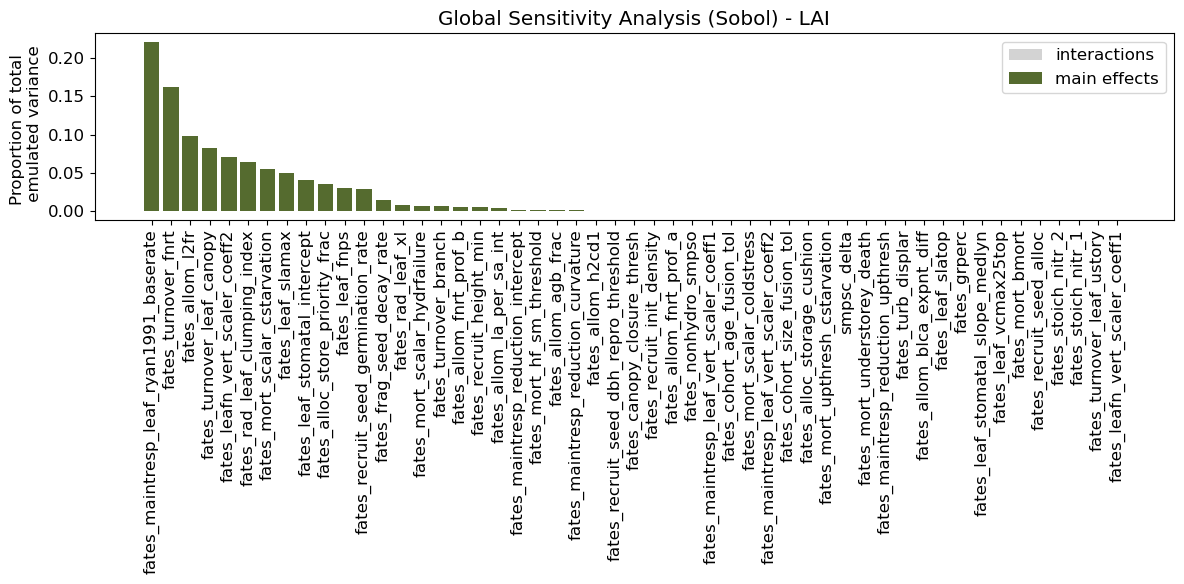

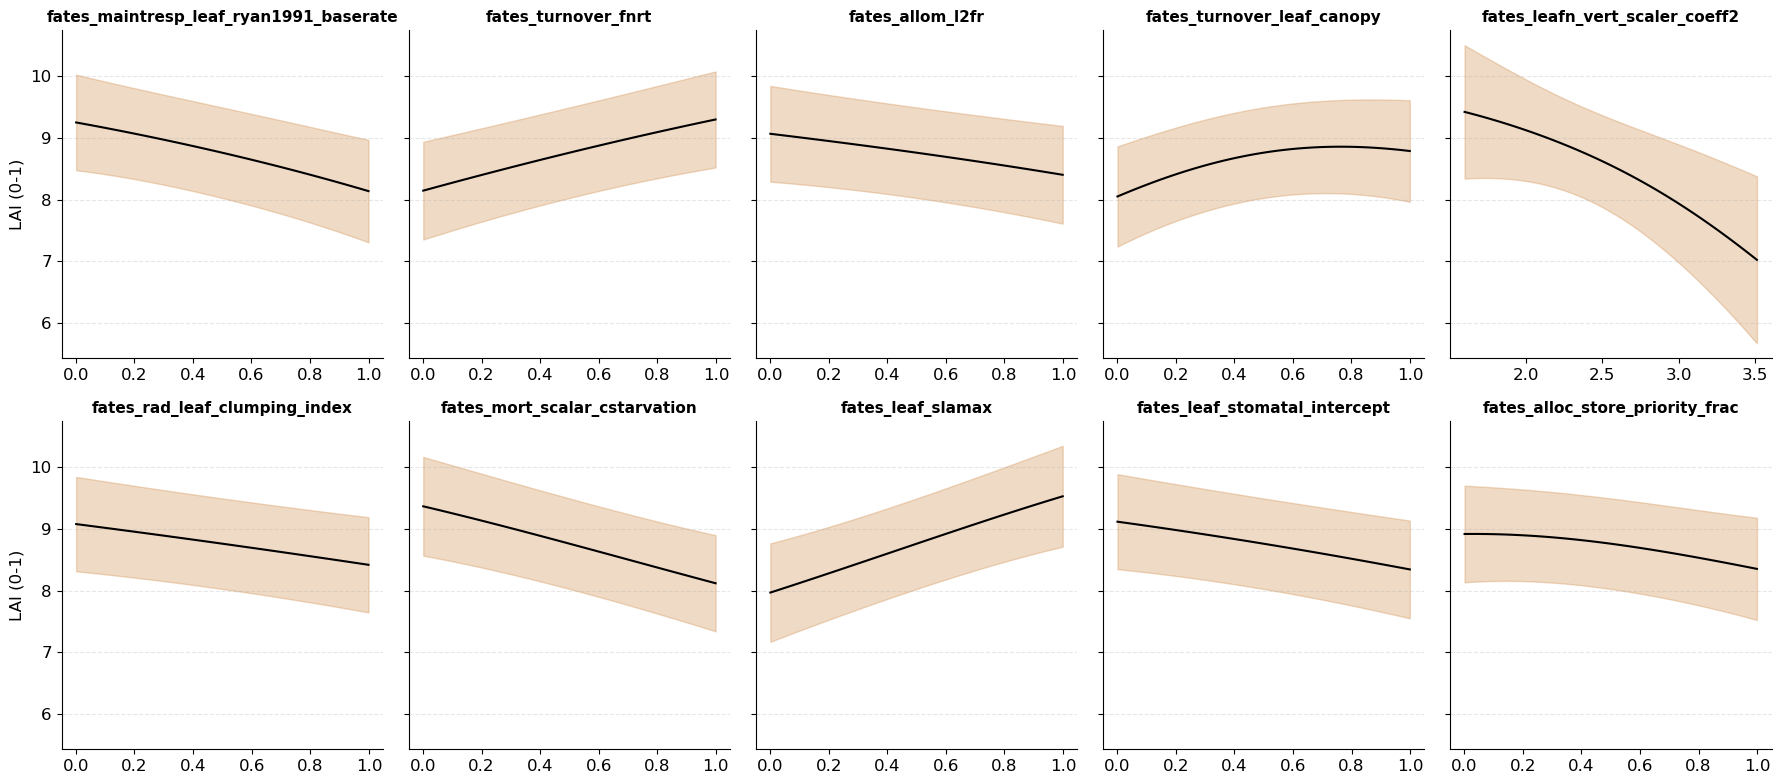

In [129]:
for i, variable in enumerate(calibration_vars):
    sens_sub = sens_df[sens_df.variable == variable]
    plotting.plot_global_sensitivity(sens_sub, calibration_labels[i])
    plt.savefig(os.path.join(fig_dir, f'{calibration_vars[i]}_sobol_{iteration}.png'))
    top_params = sens_sub.sort_values('S1', ascending=False)['parameter'][:10].values
    plotting.plot_sensitivity_grid_2rows(lh_key, top_params, emulators[i], param_names,
                                         y_label = f"{calibration_labels[i]} ({calibration_units[i]})")
    plt.savefig(os.path.join(fig_dir, f'{calibration_vars[i]}_oaat_{iteration}.png'))

In [130]:
sub_df, best_sample = em.find_best_sample(df, calibration_vars, ensemble_config['implaus_tol'])

In [131]:
sensitive_pars = em.find_sensitive_parameters(sens_df, calibration_vars,
                                              sens_tol=ensemble_config['sens_tol'])

In [132]:
update_pars = em.get_update_pars(update_pars, best_sample[sensitive_pars])

In [133]:
update_pars

,fates_allom_blca_expnt_diff,fates_leaf_slatop,fates_leaf_vcmax25top,fates_leafn_vert_scaler_coeff1,fates_recruit_seed_alloc,fates_grperc,fates_leaf_stomatal_slope_medlyn,fates_mort_bmort,fates_stoich_nitr_1,fates_stoich_nitr_2,fates_turnover_leaf_ustory,fates_alloc_store_priority_frac,fates_leaf_stomatal_intercept,fates_maintresp_leaf_ryan1991_baserate,fates_mort_hf_sm_threshold,fates_mort_scalar_cstarvation,fates_mort_scalar_hydrfailure,fates_turnover_fnrt,smpsc_delta
0,0.066157,0.693114,0.590209,0.458399,0.480923,0.069588,0.956949,0.893087,0.573131,0.275905,0.921858,0.940634,0.79321,0.094216,0.362275,0.576209,0.892743,0.218514,0.042658
